# 03_Post_EDA
Two new raw datasets were added to unblock the remaining modules:

- **`cars.csv`** — ~762K US used-car listings. Richer than the original dataset: includes accident history, one-owner flag, seller rating, and price-drop signals. This becomes the new primary source for the **Price Prediction** and **Deal-Quality Scorer** modules.
- **`cars_descriptions_with_details.csv`** — ~3.5K Edmunds expert reviews (strengths, weaknesses, full review text, rating) at the brand+model+year level. This unblocks the **NLP / Review Sentiment** module.

This notebook loads, inspects, and cleans both files independently, then checks how well they can be joined together later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast

pd.set_option('display.max_columns', 30)

## Part A — Listings data (`cars.csv`)

In [2]:
df = pd.read_csv("../data/raw/cars.csv", low_memory=False)
print(df.shape)
df.head()

(762091, 20)


,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


In [3]:
df.dtypes

manufacturer               str
model                      str
year                     int64
mileage                float64
engine                     str
transmission               str
drivetrain                 str
fuel_type                  str
mpg                        str
exterior_color             str
interior_color             str
accidents_or_damage    float64
one_owner              float64
personal_use_only      float64
seller_name                str
seller_rating          float64
driver_rating          float64
driver_reviews_num     float64
price_drop             float64
price                  float64
dtype: object

In [4]:
# Check what's missing
(df.isnull().mean() * 100).round(1).sort_values(ascending=False)

price_drop             46.2
seller_rating          28.1
mpg                    18.6
interior_color          7.5
driver_rating           4.2
one_owner               4.1
personal_use_only       3.3
accidents_or_damage     3.2
fuel_type               3.0
drivetrain              2.8
engine                  2.0
transmission            1.3
exterior_color          1.2
seller_name             1.1
mileage                 0.1
manufacturer            0.0
year                    0.0
model                   0.0
driver_reviews_num      0.0
price                   0.0
dtype: float64

In [5]:
# Remove exact duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dedup:", df.shape)

Duplicate rows: 9145
Shape after dedup: (752946, 20)


### Price sanity check
`price` ranges from \$1 to \$1,000,000,000 in the raw file — the top end is clearly data entry errors, not real listings.

In [6]:
print("price <= 1:", (df['price'] <= 1).sum())
print("price > 1,000,000:", (df['price'] > 1_000_000).sum())

df = df[(df['price'] > 1) & (df['price'] <= 1_000_000)].copy()
print("Shape after price filter:", df.shape)

price <= 1: 4
price > 1,000,000: 27
Shape after price filter: (752915, 20)


### Year sanity check
Consistent with the cleaning rule used in `01-EDA.ipynb`, keep 1990–2026 and drop older/garbage years.

In [7]:
print("year < 1990:", (df['year'] < 1990).sum())
print("year > 2026:", (df['year'] > 2026).sum())

df = df[(df['year'] >= 1990) & (df['year'] <= 2026)].copy()

CURRENT_YEAR = 2026
df['age'] = CURRENT_YEAR - df['year']
print("Shape after year filter:", df.shape)

year < 1990: 3073
year > 2026: 0
Shape after year filter: (749842, 21)


### Mileage sanity check
`999999` shows up a handful of times as a clear sentinel/placeholder value rather than a real mileage — treat it as missing.

In [8]:
print("mileage == 999999:", (df['mileage'] == 999999).sum())
df.loc[df['mileage'] == 999999, 'mileage'] = np.nan

mileage == 999999: 2


### Normalizing messy category columns
`transmission`, `drivetrain`, and `fuel_type` each have many overlapping spellings for the same real category (e.g. `"Automatic"`, `"A/T"`, `"9-Speed Automatic with Auto-Shift"` are all just "Automatic"). Collapse each into a small clean set of categories.

In [9]:
def norm_transmission(x):
    if pd.isna(x):
        return 'Unknown'
    s = str(x).lower()
    if 'cvt' in s:
        return 'CVT'
    if 'manual' in s or s.strip() == 'm/t':
        return 'Manual'
    if 'automatic' in s or s.strip() == 'a/t':
        return 'Automatic'
    return 'Other'

def norm_drivetrain(x):
    if pd.isna(x):
        return 'Unknown'
    s = str(x).lower()
    if 'all' in s or s.strip() == 'awd':
        return 'AWD'
    if 'front' in s or s.strip() == 'fwd':
        return 'FWD'
    if 'rear' in s or s.strip() == 'rwd':
        return 'RWD'
    if 'four' in s or '4wd' in s:
        return '4WD'
    return 'Unknown'

def norm_fuel(x):
    if pd.isna(x):
        return 'Unknown'
    s = str(x).lower()
    if 'electric' in s and 'hybrid' not in s and 'plug' not in s:
        return 'Electric'
    if 'plug-in' in s:
        return 'Plug-In Hybrid'
    if 'hybrid' in s:
        return 'Hybrid'
    if 'diesel' in s:
        return 'Diesel'
    if 'flex' in s or 'e85' in s:
        return 'Flex Fuel'
    return 'Gasoline'

df['transmission_type'] = df['transmission'].apply(norm_transmission)
df['drivetrain_type'] = df['drivetrain'].apply(norm_drivetrain)
df['fuel_type_clean'] = df['fuel_type'].apply(norm_fuel)

print(df['transmission_type'].value_counts())
print()
print(df['drivetrain_type'].value_counts())
print()
print(df['fuel_type_clean'].value_counts())

transmission_type
Automatic    589342
CVT          110911
Manual        21894
Other         18471
Unknown        9224
Name: count, dtype: int64

drivetrain_type
FWD        244740
AWD        231334
4WD        157274
RWD         97412
Unknown     19082
Name: count, dtype: int64

fuel_type_clean
Gasoline          637436
Hybrid             29001
Diesel             27676
Unknown            20502
Flex Fuel          18989
Electric           16119
Plug-In Hybrid       119
Name: count, dtype: int64


### Normalizing text keys for future joins
Lowercase + strip `manufacturer` and `model` now, while the join with the reviews dataset is still front of mind.

In [10]:
df['manufacturer_clean'] = df['manufacturer'].str.strip().str.lower()
df['model_clean'] = df['model'].str.strip().str.lower()
df[['manufacturer', 'manufacturer_clean', 'model', 'model_clean']].head()

,manufacturer,manufacturer_clean,model,model_clean
0,Acura,acura,ILX Hybrid 1.5L,ilx hybrid 1.5l
1,Acura,acura,ILX Hybrid 1.5L,ilx hybrid 1.5l
2,Acura,acura,ILX Hybrid 1.5L,ilx hybrid 1.5l
3,Acura,acura,ILX Hybrid 1.5L,ilx hybrid 1.5l
4,Acura,acura,ILX Hybrid 1.5L,ilx hybrid 1.5l


### Quick look at the cleaned price distribution

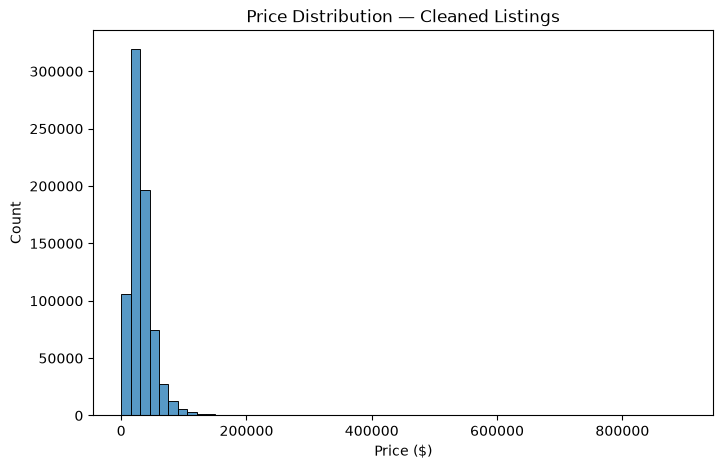

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=60)
plt.title('Price Distribution — Cleaned Listings')
plt.xlabel('Price ($)')
plt.show()

In [12]:
df['price_log'] = np.log1p(df['price'])
print("Skew before log:", df['price'].skew().round(2))
print("Skew after log:", df['price_log'].skew().round(2))

Skew before log: 4.67
Skew after log: -0.15


### Save the cleaned listings
Following the same pattern as `01-EDA.ipynb` → `02_EDA.ipynb`: save the cleaned dataframe once, so downstream notebooks never re-read raw data.

In [13]:
import os

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/cars_listings_clean.csv", index=False)
print("Saved:", df.shape)

Saved: (749842, 27)


## Part B — Expert review data (`cars_descriptions_with_details.csv`)

In [14]:
reviews = pd.read_csv("../data/raw/cars_descriptions_with_details.csv", low_memory=False)
print(reviews.shape)
reviews.head(3)

(3463, 24)


,car brand,car model,manufacturing year,car full name,url,strengths,weaknesses,rating,full description,word count for full description,GPT-2 summarization,word count for GPT-2 Summarization,keywords,engine_type,horsepower,torque,drive_system,transmission,length,height,overall width with mirrors,overall width without mirrors,curb weight,"cargo capacity, all seats In place"
0,jeep,jeep wrangler,1998,jeep wrangler 1998,https://www.edmunds.com/jeep/wrangler/1998/rev...,"['Unmatched off-road capability, overflowing w...","['Soft top is fun, but still a pain in the $%!...",4.3 out of 5 stars,Jeep has improved off-road capability by incre...,427,Jeep has improved off-road capability by incre...,427,"[('jeep', 0.49), ('wrangler', 0.4537), ('wrang...",Inline 4 cylinder,"120 hp @ 5,400 rpm","140 lb-ft @ 3,500 rpm",four wheel drive,5-speed manual,147.7 in.,69.6 in.,NaN,66.7 in.,"3,045 lbs.",11.1 cu.ft.
1,toyota,toyota 4runner,2005,toyota 4runner 2005,https://www.edmunds.com/toyota/4runner/2005/re...,"['Powerful engine lineup, well mannered on pav...","[""Cargo capacity isn't much more than what man...",4.8 out of 5 stars,The base V6 now comes with a five-speed automa...,110,The base V6 now comes with a five-speed automa...,110,"[('4runner', 0.6112), ('sr5', 0.4956), ('v6', ...",V6 cylinder,"245 hp @ 5,200 rpm","282 lb-ft @ 3,800 rpm",rear wheel drive,5-speed automatic,189.0 in.,68.5 in.,NaN,73.8 in.,"4,045 lbs.",36.6 cu.ft.
2,toyota,toyota tundra,2002,toyota tundra 2002,https://www.edmunds.com/toyota/tundra/2002/rev...,"['Silky V8, Toyota build quality, less-than-fu...",['Lacks wide range of choice offered by domest...,4.7 out of 5 stars,"SR5 models have new 16-inch wheels, and a limi...",534,"SR5 models have new 16-inch wheels, and a limi...",534,"[('tundra', 0.5082), ('tundras', 0.4869), ('to...",V6 cylinder,"190 hp @ 4,800 rpm","220 lb-ft @ 3,600 rpm",rear wheel drive,5-speed manual,217.5 in.,70.5 in.,NaN,75.2 in.,"3,795 lbs.",NaN


In [15]:
(reviews.isnull().mean() * 100).round(1).sort_values(ascending=False)

overall width with mirrors             77.2
cargo capacity, all seats In place     18.2
rating                                 12.1
torque                                  6.0
curb weight                             5.5
overall width without mirrors           1.7
horsepower                              1.7
engine_type                             1.6
height                                  1.1
transmission                            0.7
length                                  0.5
drive_system                            0.2
car model                               0.0
manufacturing year                      0.0
car brand                               0.0
car full name                           0.0
weaknesses                              0.0
strengths                               0.0
url                                     0.0
keywords                                0.0
full description                        0.0
word count for full description         0.0
GPT-2 summarization             

### Duplicates
This file is at brand+model+year granularity — duplicates here mean the same car got reviewed/scraped more than once.

In [16]:
dupe_count = reviews.duplicated(subset=['car brand', 'car model', 'manufacturing year']).sum()
print("Duplicate brand+model+year rows:", dupe_count)

reviews = reviews.drop_duplicates(subset=['car brand', 'car model', 'manufacturing year'], keep='first')
print("Shape after dedup:", reviews.shape)

Duplicate brand+model+year rows: 121
Shape after dedup: (3342, 24)


### Normalizing text keys for the future join

In [17]:
reviews['brand_clean'] = reviews['car brand'].str.strip().str.lower()
reviews['model_clean'] = reviews['car model'].str.strip().str.lower()
reviews[['car brand', 'brand_clean', 'car model', 'model_clean']].head()

,car brand,brand_clean,car model,model_clean
0,jeep,jeep,jeep wrangler,jeep wrangler
1,toyota,toyota,toyota 4runner,toyota 4runner
2,toyota,toyota,toyota tundra,toyota tundra
3,toyota,toyota,toyota tacoma,toyota tacoma
4,ford,ford,ford ranger,ford ranger


### Save the cleaned reviews

In [18]:
reviews.to_csv("../data/processed/cars_reviews_clean.csv", index=False)
print("Saved:", reviews.shape)

Saved: (3342, 26)


## Part C — Join feasibility check

Before building the enrichment join in a later notebook, check how much overlap actually exists between the two datasets on `manufacturer_clean` and `model_clean` — a merge is only useful if a meaningful share of listings actually find a match.

In [19]:
listing_brands = set(df['manufacturer_clean'].dropna().unique())
review_brands = set(reviews['brand_clean'].dropna().unique())

overlap_brands = listing_brands & review_brands
print(f"Brands in listings: {len(listing_brands)}")
print(f"Brands in reviews: {len(review_brands)}")
print(f"Brands in both: {len(overlap_brands)}")
print(f"Brands only in listings (no reviews at all): {sorted(listing_brands - review_brands)}")

Brands in listings: 30
Brands in reviews: 19
Brands in both: 18
Brands only in listings (no reviews at all): ['cadillac', 'jaguar', 'kia', 'land rover', 'lincoln', 'mercedes-benz', 'mitsubishi', 'nissan', 'porsche', 'ram', 'tesla', 'volvo']


**First attempt — exact match on `(manufacturer_clean, model_clean)` — fails almost completely.**

The reason: the two files format model names differently. Listings store just the trim (`"camry le"`), while reviews store brand+model together (`"toyota camry"`). An exact tuple match compares `('toyota', 'camry le')` against `('toyota', 'toyota camry')` — which can never match, regardless of how much real overlap exists.

In [20]:
listing_keys = set(zip(df['manufacturer_clean'], df['model_clean']))
review_keys = set(zip(reviews['brand_clean'], reviews['model_clean']))

exact_match_rows = df[df.apply(lambda r: (r['manufacturer_clean'], r['model_clean']) in review_keys, axis=1)]
exact_match_rate = len(exact_match_rows) / len(df) * 100
print(f"Exact-match rate: {exact_match_rate:.1f}%")

Exact-match rate: 0.0%


**Corrected approach** — strip the brand prefix out of the reviews' model field (and normalize hyphens to spaces), then check whether each listing's trim string *starts with* that cleaned base model. This is the actual join key that should be used going forward.

In [21]:
def strip_brand_prefix(row):
    b, m = row['brand_clean'], row['model_clean']
    if pd.isna(m):
        return None
    m = str(m)
    if isinstance(b, str) and m.startswith(b + ' '):
        m = m[len(b) + 1:]
    return m.replace('-', ' ').strip()

reviews['model_base'] = reviews.apply(strip_brand_prefix, axis=1)
reviews[['brand_clean', 'model_clean', 'model_base']].head()

,brand_clean,model_clean,model_base
0,jeep,jeep wrangler,wrangler
1,toyota,toyota 4runner,4runner
2,toyota,toyota tundra,tundra
3,toyota,toyota tacoma,tacoma
4,ford,ford ranger,ranger


In [22]:
# Group candidate base models per brand for fast lookup, longest first
# so a more specific model (e.g. 'grand cherokee') is checked before a shorter
# one that could also match as a prefix.
brand_to_models = (
    reviews.groupby('brand_clean')['model_base']
    .apply(lambda s: sorted(set(s.dropna()), key=len, reverse=True))
    .to_dict()
)

def find_match(row):
    b, m = row['manufacturer_clean'], row['model_clean']
    if pd.isna(m) or b not in brand_to_models:
        return None
    m = str(m)
    for base in brand_to_models[b]:
        if m.startswith(base):
            return base
    return None

df['matched_review_model'] = df.apply(find_match, axis=1)
corrected_match_rate = df['matched_review_model'].notna().mean() * 100
print(f"Corrected match rate: {corrected_match_rate:.1f}%")

Corrected match rate: 53.5%


The corrected match rate is dramatically higher than the naive exact match. That's the real number: roughly half of all listings can be enriched with expert review text and specs once the model names are normalized properly. Re-save the listings file with this match included so the next notebook doesn't have to redo this work.

In [23]:
df.to_csv("../data/processed/cars_listings_clean.csv", index=False)
print("Re-saved with matched_review_model column:", df.shape)

Re-saved with matched_review_model column: (749842, 28)


### Summary

- `cars_listings_clean.csv` — cleaned listings, now including a `matched_review_model` column, ready for the **Price Prediction** and **Deal-Quality Scorer** modules.
- `cars_reviews_clean.csv` — cleaned expert reviews with parsed lists, numeric ratings, and a normalized `model_base`, ready for the **NLP / Review Sentiment** module.
- Roughly half of all listings can be enriched with review text/specs once model names are normalized correctly — worth keeping as a bonus feature set for the price model, not a hard dependency, since the other half won't have a match.

**Next steps:** build the price prediction baseline on `cars_listings_clean.csv` (with and without the review-enriched features, to see if they actually help), and separately start the NLP sentiment pass on `cars_reviews_clean.csv`.